In [1]:
def clean(df):
    
    print(' Old size: %d' % len(df))
    # remove any null data
    df = df.dropna(how = 'any', axis = 'rows')
    print(' New size after dropna: %d' % len(df))  
    
    # Remove inconsistent values
    df = df[(df['dropoff_longitude'] != df['pickup_longitude']) & (df['dropoff_latitude'] != df['pickup_latitude'])]
    print(' New size after removing same long lat: %d' % len(df))                 
    
    df = df[(df['dropoff_longitude'] != 0) & (df['pickup_longitude'] != 0) & (df['dropoff_latitude'] != 0) & (df['pickup_latitude'] != 0)] 
    print(' New size after removing 0 long lat: %d' % len(df))                          
             #pickup_longitude       40.761665
#pickup_latitude       -73.979324
#dropoff_longitude      40.851028
#dropoff_latitude      -73.928795
    MinMax = (-74.5, -72.8, 40.5, 41.8)

    #-72.986532	41.709555	-72.990963	41.696683
    # Delimiter lats and lons to NY only
    df = df[(MinMax[0] <= df['pickup_longitude']) & (df['pickup_longitude'] <= MinMax[1])]
    df = df[(MinMax[0] <= df['dropoff_longitude']) & (df['dropoff_longitude'] <= MinMax[1])]
    df = df[(MinMax[2] <= df['pickup_latitude']) & (df['pickup_latitude'] <= MinMax[3])]
    df = df[(MinMax[2] <= df['dropoff_latitude']) & (df['dropoff_latitude'] <= MinMax[3])]
       

    print(' New size after NYC lang lot: %d' % len(df))         
    
    df = df[(df['pickup_latitude'] != 0)]
    df = df[(df['pickup_latitude'] != 0)]
    df = df[(df['dropoff_longitude']!= 0)]
    df = df[(df['dropoff_latitude'] != 0)]
    
    print(' New size after lang lot > 0: %d' % len(df))         

    df = df[((df['pickup_latitude'] - df['dropoff_latitude']).abs() > 0.001)]
    df = df[((df['pickup_longitude'] - df['dropoff_longitude']).abs() > 0.001)]
    
    print(' New size after lang - lot > 0.001: %d' % len(df))         
    
    print(' New size after only NYC: %d' % len(df)) 
    # Remove possible outliers
    df = df[(0 < df['fare_amount']) & (df['fare_amount'] <= 50)]
    
    print(' New size after removing outliers: %d' % len(df)) 
    
    # Remove passangecount  = 0
    #df = df[(df['passenger_count'] > 0)]
    df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
    print(' New size after removing 6=>passenger_count > 0 : %d' % len(df)) 
    #print(' New size after removing passenger_count > 0: %d' % len(df)) 
    
    
    
    # Remove airports
    
    nyc_coord = (40.7141667,-74.0063889) 
    fk_coord = (40.639722, -73.778889)
    ewr_coord = (40.6925, -74.168611)
    lga_coord = (40.77725, -73.872611)
    sol_coord = (40.6892,-74.0445) # Statue of Liberty
    
             

    #ny
    df = df[(nyc_coord[1] != df['pickup_longitude']) & (df['pickup_latitude'] != nyc_coord[0])]
    df = df[(nyc_coord[1] != df['dropoff_longitude']) & (df['dropoff_latitude'] != nyc_coord[0])]
    
    print(' New size after NY airport: %d' % len(df))
    
    #jfk
    df = df[(fk_coord[1] != df['pickup_longitude']) & (df['pickup_latitude'] != fk_coord[0])]
    df = df[(fk_coord[1] != df['dropoff_longitude']) & (df['dropoff_latitude'] != fk_coord[0])]
    
    print(' New size after jfk airport: %d' % len(df))
    
    #ewr
    df = df[(ewr_coord[1] != df['pickup_longitude']) & (df['pickup_latitude'] != ewr_coord[0])]
    df = df[(ewr_coord[1] != df['dropoff_longitude']) & (df['dropoff_latitude'] != ewr_coord[0])]
    
    print(' New size after ewr airport: %d' % len(df))
    #lgr
    df = df[(lga_coord[1] != df['pickup_longitude']) & (df['pickup_latitude'] != lga_coord[0])]
    df = df[(lga_coord[1] != df['dropoff_longitude']) & (df['dropoff_latitude'] != lga_coord[0])]
    

    print(' New size after lgr airport: %d' % len(df))
             
    #sol
    df = df[(sol_coord[1] != df['pickup_longitude']) & (df['pickup_latitude'] != sol_coord[0])]
    df = df[(sol_coord[1] != df['dropoff_longitude']) & (df['dropoff_latitude'] != sol_coord[0])]
    

    print(' New size after sol removed: %d' % len(df))             
    
            
    print('Old size: %d' % len(df))
    df = remove_datapoints_from_water(df)
    print('New size: %d' % len(df))
    
        
    print(' New size: %d' % len(df))
    
    return df

def remove_datapoints_from_water(df):
    def lonlat_to_xy(longitude, latitude, dx, dy, BB):
        return (dx*(longitude - BB[0])/(BB[1]-BB[0])).astype('int'), \
               (dy - dy*(latitude - BB[2])/(BB[3]-BB[2])).astype('int')

    # define bounding box
    BB = (-74.5, -72.8, 40.5, 41.8)
    
    # read nyc mask and turn into boolean map with
    # land = True, water = False
    nyc_mask = plt.imread('https://aiblog.nl/download/nyc_mask-74.5_-72.8_40.5_41.8.png')[:,:,0] > 0.9
    
    # calculate for each lon,lat coordinate the xy coordinate in the mask map
    pickup_x, pickup_y = lonlat_to_xy(df.pickup_longitude, df.pickup_latitude, 
                                      nyc_mask.shape[1], nyc_mask.shape[0], BB)
    dropoff_x, dropoff_y = lonlat_to_xy(df.dropoff_longitude, df.dropoff_latitude, 
                                      nyc_mask.shape[1], nyc_mask.shape[0], BB)    
    # calculate boolean index
    idx = nyc_mask[pickup_y, pickup_x] & nyc_mask[dropoff_y, dropoff_x]
    
    # return only datapoints on land
    return df[idx]
    
def late_night (row):
     if (row['hour'] <= 3) or (row['hour'] >= 0):
        return 1
     else:
        return 0


def night (row):
    if ((row['hour'] > 20) and (row['hour'] > 0)) and (row['weekday'] < 5):
        return 1
    else:
        return 0
    
def rush_hour (row):
    if ((row['hour'] <= 20) and (row['hour'] >= 16)) and (row['weekday'] < 5):
        return 1
    else:
        return 0   
    
# def rush_hour (row): from 8 to 10 and from 17 to 19 Weekdays
# def weekend_night (row): from 8 to 10 and from 20 to 24 and 0 to 2 weekends
# def weekday (row): Monday, Tuesday, wednesday, Thursday
# def weekend (row): Friday, Saturday and Sunday

       
    
    
def manhattan(pickup_lat, pickup_long, dropoff_lat, dropoff_long):
    return np.abs(dropoff_lat - pickup_lat) + np.abs(dropoff_long - pickup_long)


def add_time_features(df):
    df['pickup_datetime'] =  pd.to_datetime(df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S %Z')
    df['year'] = df['pickup_datetime'].apply(lambda x: x.year)
    df['month'] = df['pickup_datetime'].apply(lambda x: x.month)
    df['day'] = df['pickup_datetime'].apply(lambda x: x.day)
    df['hour'] = df['pickup_datetime'].apply(lambda x: x.hour)
    df['weekday'] = df['pickup_datetime'].apply(lambda x: x.weekday())
    df['pickup_datetime'] =  df['pickup_datetime'].apply(lambda x: str(x))
    df['night'] = df.apply (lambda x: night(x), axis=1)
    df['late_night'] = df.apply (lambda x: late_night(x), axis=1)
    df['rush_hour'] = df.apply (lambda x: rush_hour(x), axis=1)
    # Drop 'pickup_datetime' as we won't need it anymore
    #df = df.drop('pickup_datetime', axis=1)
    
    return df


def add_coordinate_features(df):
    lat1 = df['pickup_latitude']
    lat2 = df['dropoff_latitude']
    lon1 = df['pickup_longitude']
    lon2 = df['dropoff_longitude']
    
    # Add new features
    df['latdiff'] = (lat1 - lat2).abs()
    df['londiff'] = (lon1 - lon2).abs()
    
    
    return df


def add_distances_features(df):
    
    lat1 = df['pickup_latitude']
    lat2 = df['dropoff_latitude']
    lon1 = df['pickup_longitude']
    lon2 = df['dropoff_longitude']
    
    df['manhattan'] = manhattan(lat1, lon1, lat2, lon2)
    df['distance'] = np.sqrt(np.abs(df['pickup_longitude']-df['dropoff_longitude'])**2 + np.abs(df['pickup_latitude']-df['dropoff_latitude'])**2)
    #df['distance'] = distance(lat1, lon1, lat2, lon2)
    #df['distance_miles'] = distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
    
  
    return df

# This function is based on https://stackoverflow.com/questions/27928/
# calculate-distance-between-two-latitude-longitude-points-haversine-formula 
# return distance in miles
def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295 # Pi/180
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a)) # 2*R*asin...
# This function is based on https://stackoverflow.com/questions/27928/
# calculate-distance-between-two-latitude-longitude-points-haversine-formula 
# return distance in miles
def distanceP(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295 # Pi/180
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a)) # 2*R*asin...
    
def output_submission(raw_test, prediction, id_column, prediction_column, file_name):
    df = pd.DataFrame(prediction, columns=[prediction_column])
    df[id_column] = raw_test[id_column]
    df[[id_column, prediction_column]].to_csv((file_name), index=False)
    print('Output complete')
    
    
def plot_loss_accuracy_rmse(history):
    
    plt.figure(figsize=(20,10))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()
    
    
    plt.figure(figsize=(20,10))
    plt.plot(history.history['rmse'])
    plt.plot(history.history['val_rmse'])
    plt.title('Model rmse')
    plt.ylabel('rmse')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()
    
    


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, LSTM
from keras.callbacks import EarlyStopping
from keras import optimizers
from keras import regularizers

TRAIN_PATH = '../input/train.csv'
TEST_PATH = '../input/test.csv'
SUBMISSION_NAME = 'submissiontry_water.csv'



# Model parameters
BATCH_SIZE = 256
#BATCH_SIZE = 1000
EPOCHS = 100
LEARNING_RATE = 0.001
DATASET_SIZE = 80000


2026-01-07 05:55:37.450840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767765337.463948      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767765337.467909      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 05:55:37.484105: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
# Load values in a more compact form
datatypes = {'key': 'str', 
              'fare_amount': 'float32',
              'pickup_datetime': 'str', 
              'pickup_longitude': 'float32',
              'pickup_latitude': 'float32',
              'dropoff_longitude': 'float32',
              'dropoff_latitude': 'float32',
              'passenger_count': 'uint8'}

trainKaggle = pd.read_csv(TRAIN_PATH, nrows=DATASET_SIZE, dtype=datatypes, usecols=[1,2,3,4,5,6,7])
testKaggle = pd.read_csv(TEST_PATH)    


In [4]:
train_df, test_df = train_test_split(trainKaggle, test_size=0.50, random_state=1)
test_df = test_df[:10000]


In [5]:
#train_df, validation_df = train_test_split(train_df, test_size=0.10, random_state=1)


In [6]:
print('testKaggle Size %d' % len(testKaggle))
print('train_df Size %d' % len(train_df))
print('test_df Size %d' % len(test_df))


testKaggle Size 9914
train_df Size 40000
test_df Size 10000


In [7]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,1.668275
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.295907
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,1.000000
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,1.000000
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2.000000
max,180.000000,40.783470,43.183331,40.802437,43.415192,6.000000


In [8]:
test_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.370206,-72.572372,39.962261,-72.563927,39.958992,1.668300
std,9.563587,10.160276,5.835522,10.186098,5.849215,1.298863
min,-2.500000,-74.229141,-73.979324,-74.227051,-73.986359,0.000000
25%,6.000000,-73.992228,40.734276,-73.991226,40.734427,1.000000
50%,8.500000,-73.982101,40.752495,-73.980183,40.753588,1.000000
75%,12.900000,-73.967705,40.767259,-73.964073,40.768030,2.000000
max,143.000000,40.761665,41.523216,40.851028,41.543217,6.000000


In [9]:
# Only a fraction of the whole data

print('train_df clean')
train_df = clean(train_df)
test_df = clean(test_df)


train_df clean
 Old size: 40000
 New size after dropna: 40000
 New size after removing same long lat: 38825
 New size after removing 0 long lat: 38754
 New size after NYC lang lot: 38702
 New size after lang lot > 0: 38702
 New size after lang - lot > 0.001: 36058
 New size after only NYC: 36058
 New size after removing outliers: 35611
 New size after removing 6=>passenger_count > 0 : 35472
 New size after NY airport: 35462
 New size after jfk airport: 35462
 New size after ewr airport: 35462
 New size after lgr airport: 35457
 New size after sol removed: 35457
Old size: 35457


ValueError: Please open the URL for reading and pass the result to Pillow, e.g. with ``np.array(PIL.Image.open(urllib.request.urlopen(url)))``.

In [10]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,1.668275
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.295907
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,1.000000
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,1.000000
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2.000000
max,180.000000,40.783470,43.183331,40.802437,43.415192,6.000000


In [11]:
print('train_df add_time_features')
train_df = add_time_features(train_df)
print('test_df add_time_features')
test_df = add_time_features(test_df)
print('testKaggle add_time_features')
testKaggle = add_time_features(testKaggle)


   


train_df add_time_features
test_df add_time_features
testKaggle add_time_features


In [12]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.0,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,1.668275,2011.748575,6.243400,15.689975,13.499575,3.043100,0.119000,1.0,0.201225
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.295907,1.865220,3.453209,8.656121,6.511360,1.951612,0.323793,0.0,0.400921
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,1.0,0.000000
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,1.0,0.000000
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,1.0,0.000000
max,180.000000,40.783470,43.183331,40.802437,43.415192,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.0,1.000000


In [13]:
print('train_df add_coordinate_features')
add_coordinate_features(train_df)
print('test_df add_coordinate_features Disabled!')
add_coordinate_features(test_df)
print('testKaggle add_coordinate_features')
add_coordinate_features(testKaggle)


train_df add_coordinate_features
test_df add_coordinate_features Disabled!
testKaggle add_coordinate_features


,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff
0,2010-10-01 21:26:11.0000001,2010-10-01 21:26:11+00:00,-73.983130,40.761970,-73.994386,40.749236,1,2010,10,1,21,4,1,1,0,0.012734,0.011256
1,2013-10-06 01:38:00.00000083,2013-10-06 01:38:00+00:00,-73.948505,40.753977,-73.808195,40.731952,2,2013,10,6,1,6,0,1,0,0.022025,0.140310
2,2012-03-30 19:13:53.0000001,2012-03-30 19:13:53+00:00,-73.973964,40.791979,-73.979018,40.785544,1,2012,3,30,19,4,0,1,1,0.006435,0.005054
3,2012-02-08 02:57:23.0000001,2012-02-08 02:57:23+00:00,-73.991478,40.738907,-73.907198,40.861572,2,2012,2,8,2,2,0,1,0,0.122665,0.084280
4,2013-12-13 22:56:00.000000237,2013-12-13 22:56:00+00:00,-73.986281,40.740067,-73.933927,40.856781,2,2013,12,13,22,4,1,1,0,0.116714,0.052354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2010-12-02 01:44:39.0000002,2010-12-02 01:44:39+00:00,-73.992667,40.734183,-73.995432,40.739215,4,2010,12,2,1,3,0,1,0,0.005032,0.002765
9910,2010-06-07 16:17:38.0000003,2010-06-07 16:17:38+00:00,0.000000,0.000000,0.000000,0.000000,1,2010,6,7,16,0,0,1,1,0.000000,0.000000
9911,2013-11-01 08:37:36.0000003,2013-11-01 08:37:36+00:00,-73.990315,40.746236,-73.991841,40.733516,1,2013,11,1,8,4,0,1,0,0.012720,0.001526
9912,2011-05-03 10:14:00.000000123,2011-05-03 10:14:00+00:00,-73.956110,40.787588,-73.971877,40.765808,1,2011,5,3,10,1,0,1,0,0.021780,0.015767


In [14]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.0,40000.000000,40000.000000,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,1.668275,2011.748575,6.243400,15.689975,13.499575,3.043100,0.119000,1.0,0.201225,0.090412,0.159278
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.295907,1.865220,3.453209,8.656121,6.511360,1.951612,0.323793,0.0,0.400921,1.676268,3.170623
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,1.0,0.000000,0.006630,0.005737
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,1.0,0.000000,0.013866,0.012482
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,1.0,0.000000,0.027001,0.023987
max,180.000000,40.783470,43.183331,40.802437,43.415192,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.0,1.000000,40.786671,74.039032


In [15]:
print('train_df add_distances_features')
train_df = add_distances_features(train_df)
print('test_df add_distances_features')
test_df = add_distances_features(test_df)
print('testKaggle add_distances_features')
testKaggle = add_distances_features(testKaggle)


print('Done with Adding features')


train_df add_distances_features
test_df add_distances_features
testKaggle add_distances_features
Done with Adding features


In [16]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.0,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,1.668275,2011.748575,6.243400,15.689975,13.499575,3.043100,0.119000,1.0,0.201225,0.090412,0.159278,0.249690,0.190558
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.295907,1.865220,3.453209,8.656121,6.511360,1.951612,0.323793,0.0,0.400921,1.676268,3.170623,4.756975,3.585903
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,1.0,0.000000,0.006630,0.005737,0.015914,0.012458
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,1.0,0.000000,0.013866,0.012482,0.027727,0.021536
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,1.0,0.000000,0.027001,0.023987,0.050532,0.038416
max,180.000000,40.783470,43.183331,40.802437,43.415192,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.0,1.000000,40.786671,74.039032,114.768753,84.502594


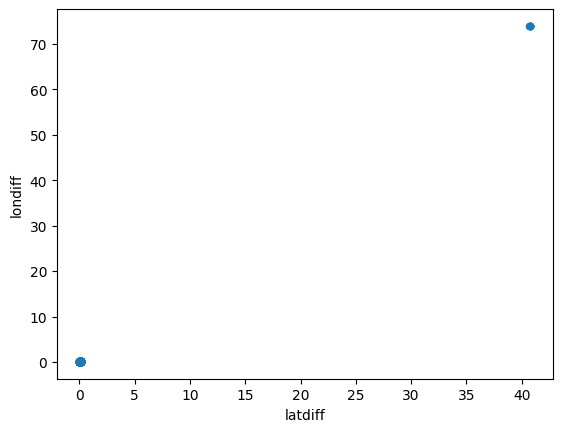

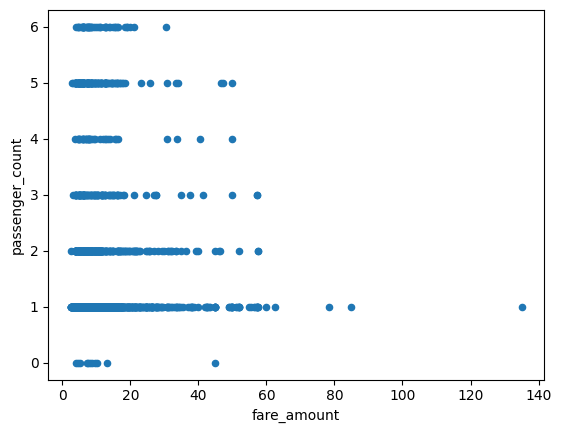

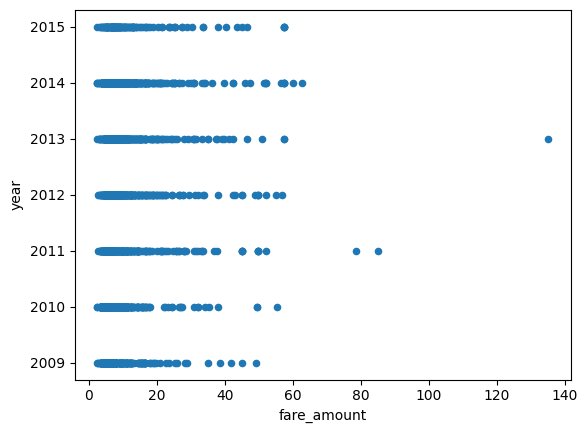

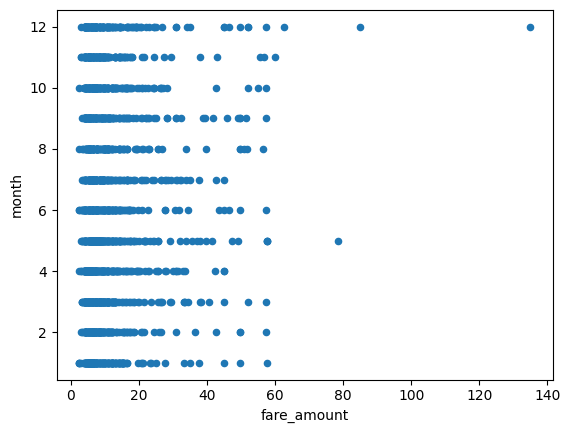

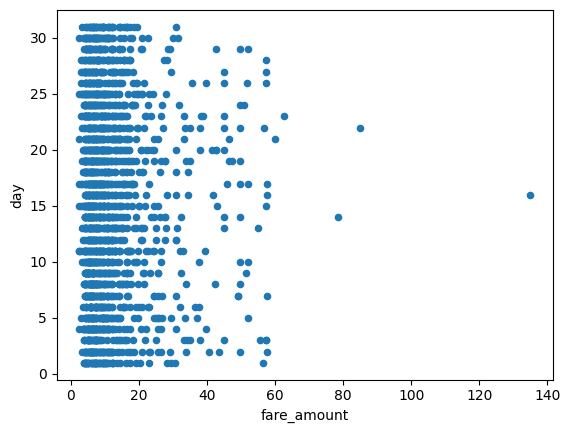

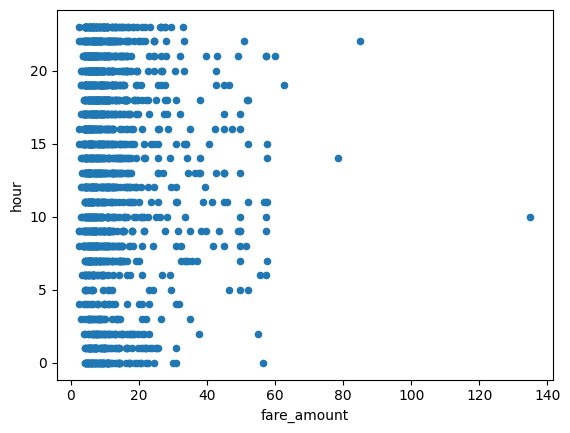

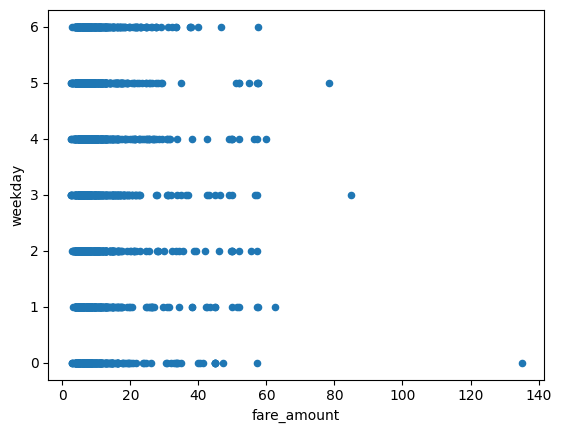

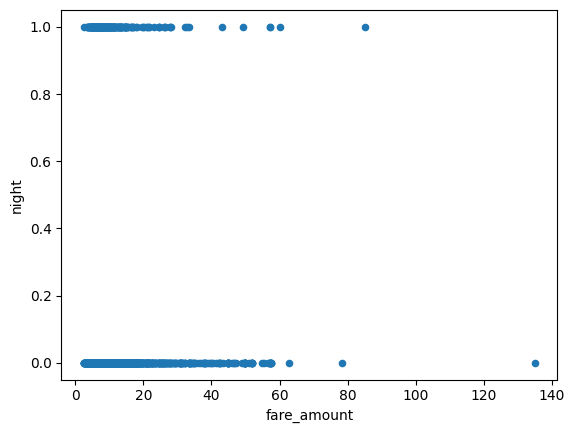

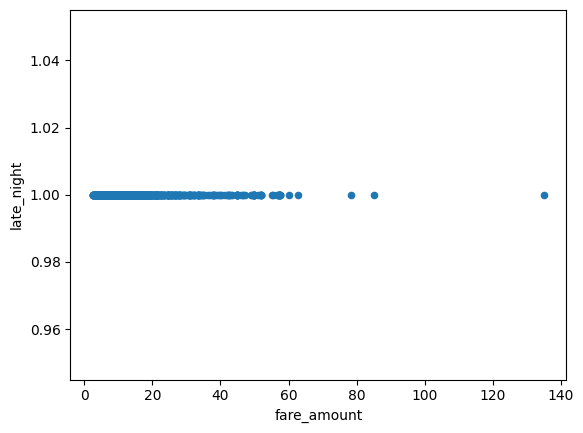

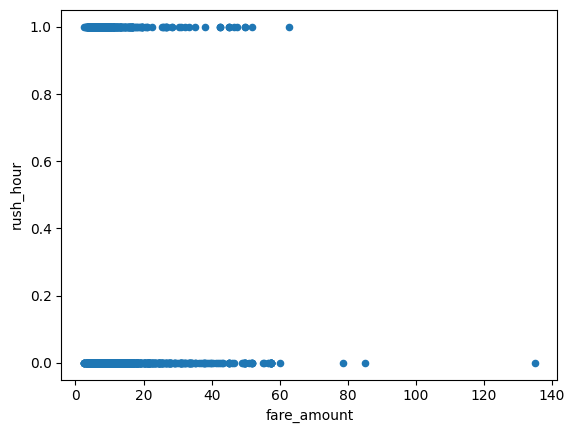

In [17]:
plot = train_df.iloc[:2000].plot.scatter('latdiff', 'londiff')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'passenger_count')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'year')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'month')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'day')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'hour')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'weekday')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'night')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'late_night')
plot = train_df.iloc[:2000].plot.scatter('fare_amount', 'rush_hour')


In [18]:
# Drop unwanted columns
dropped_columns = ['passenger_count', 'pickup_datetime'] #'pickup_latitude','pickup_longitude', 'dropoff_longitude', 'dropoff_latitude']

train_df = train_df.drop(dropped_columns, axis=1)
test_df = test_df.drop(dropped_columns, axis=1)
#validation_df = validation_df.drop(dropped_columns, axis=1)
testKaggle_clean = testKaggle.drop(dropped_columns + ['key'], axis=1)

print('Done with dropped_columns')


Done with dropped_columns


In [19]:
train_df.shape


(40000, 17)

In [20]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.0,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,2011.748575,6.243400,15.689975,13.499575,3.043100,0.119000,1.0,0.201225,0.090412,0.159278,0.249690,0.190558
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.865220,3.453209,8.656121,6.511360,1.951612,0.323793,0.0,0.400921,1.676268,3.170623,4.756975,3.585903
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,1.0,0.000000,0.006630,0.005737,0.015914,0.012458
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,1.0,0.000000,0.013866,0.012482,0.027727,0.021536
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,1.0,0.000000,0.027001,0.023987,0.050532,0.038416
max,180.000000,40.783470,43.183331,40.802437,43.415192,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.0,1.000000,40.786671,74.039032,114.768753,84.502594


In [21]:
test_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.370206,-72.572372,39.962261,-72.563927,39.958992,2011.691400,6.333400,15.708100,13.451300,3.00110,0.119100,1.0,0.201900,0.098879,0.162859,0.261738,0.194370
std,9.563587,10.160276,5.835522,10.186098,5.849215,1.860998,3.439713,8.716071,6.540513,1.95353,0.323922,0.0,0.401438,1.773789,3.219570,4.993246,3.675654
min,-2.500000,-74.229141,-73.979324,-74.227051,-73.986359,2009.000000,1.000000,1.000000,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992228,40.734276,-73.991226,40.734427,2010.000000,3.000000,8.000000,9.000000,1.00000,0.000000,1.0,0.000000,0.006658,0.005728,0.015863,0.012523
50%,8.500000,-73.982101,40.752495,-73.980183,40.753588,2012.000000,6.000000,16.000000,14.000000,3.00000,0.000000,1.0,0.000000,0.014196,0.012630,0.027954,0.021787
75%,12.900000,-73.967705,40.767259,-73.964073,40.768030,2013.000000,9.000000,23.000000,19.000000,5.00000,0.000000,1.0,0.000000,0.027653,0.024019,0.051739,0.039548
max,143.000000,40.761665,41.523216,40.851028,41.543217,2015.000000,12.000000,31.000000,23.000000,6.00000,1.000000,1.0,1.000000,40.775459,74.003090,114.759483,84.476677


In [22]:
train_df, validation_df = train_test_split(train_df, test_size=0.10, random_state=1)


In [23]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.0,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,11.360337,-72.512352,39.918488,-72.527618,39.930294,2011.749639,6.250583,15.707889,13.487167,3.047056,0.119472,1.0,0.199694,0.091179,0.158014,0.249193,0.189689
std,9.743803,10.425803,6.159618,10.366901,6.123631,1.864046,3.450960,8.659088,6.523936,1.951211,0.324348,0.0,0.399776,1.687014,3.157928,4.761067,3.579782
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992136,40.734844,-73.991272,40.734123,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,1.0,0.000000,0.006641,0.005722,0.015926,0.012461
50%,8.500000,-73.981796,40.752575,-73.979984,40.753185,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,1.0,0.000000,0.013882,0.012482,0.027752,0.021542
75%,12.500000,-73.967108,40.767037,-73.963264,40.768188,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,1.0,0.000000,0.027069,0.024055,0.050687,0.038519
max,180.000000,40.783470,43.098709,40.786205,43.415192,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.0,1.000000,40.786671,74.039032,114.768753,84.502594


In [24]:
validation_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.0,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,11.394088,-72.258446,39.742134,-72.258736,39.762886,2011.739000,6.178750,15.528750,13.611250,3.007500,0.11475,1.0,0.215000,0.083509,0.170653,0.254162,0.198378
std,9.704659,11.394361,7.123301,11.388213,7.067386,1.875969,3.473156,8.628777,6.396785,1.955096,0.31876,0.0,0.410874,1.576124,3.282586,4.719490,3.640920
min,0.000000,-74.177162,-73.992950,-74.183975,-73.989357,2009.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992025,40.735312,-73.991138,40.734282,2010.000000,3.000000,8.000000,9.000000,1.000000,0.00000,1.0,0.000000,0.006526,0.005848,0.015840,0.012409
50%,8.500000,-73.981754,40.752542,-73.979939,40.753588,2012.000000,6.000000,15.000000,14.000000,3.000000,0.00000,1.0,0.000000,0.013632,0.012520,0.027609,0.021491
75%,12.500000,-73.967373,40.767339,-73.963360,40.768913,2013.000000,9.000000,23.000000,19.000000,5.000000,0.00000,1.0,0.000000,0.026452,0.023592,0.049033,0.037575
max,92.489998,40.764420,43.183331,40.802437,41.366138,2015.000000,12.000000,31.000000,23.000000,6.000000,1.00000,1.0,1.000000,40.778534,73.990135,114.763863,84.479095


In [25]:
# Get labels
train_labels = train_df['fare_amount'].values
validation_labels = validation_df['fare_amount'].values
test_labels = test_df['fare_amount'].values

train_df = train_df.drop(['fare_amount'], axis=1)
validation_df = validation_df.drop(['fare_amount'], axis=1)
test_df = test_df.drop(['fare_amount'], axis=1)

print('Done with Labels')


Done with Labels


In [26]:
test_labels


array([4.9, 9.5, 7. , ..., 5. , 6.1, 4.9], dtype=float32)

In [27]:
#mean = train_df.mean(axis=0)
#std = train_df.std(axis=0)
#train_df = (train_df - mean) / std
#test_df = (test_df - mean) / std
#validation_df = (validation_df - mean) / std


In [28]:
train_df.describe()


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.0,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,-72.512352,39.918488,-72.527618,39.930294,2011.749639,6.250583,15.707889,13.487167,3.047056,0.119472,1.0,0.199694,0.091179,0.158014,0.249193,0.189689
std,10.425803,6.159618,10.366901,6.123631,1.864046,3.450960,8.659088,6.523936,1.951211,0.324348,0.0,0.399776,1.687014,3.157928,4.761067,3.579782
min,-75.423851,-74.006889,-74.689827,-74.006378,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-73.992136,40.734844,-73.991272,40.734123,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,1.0,0.000000,0.006641,0.005722,0.015926,0.012461
50%,-73.981796,40.752575,-73.979984,40.753185,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,1.0,0.000000,0.013882,0.012482,0.027752,0.021542
75%,-73.967108,40.767037,-73.963264,40.768188,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,1.0,0.000000,0.027069,0.024055,0.050687,0.038519
max,40.783470,43.098709,40.786205,43.415192,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.0,1.000000,40.786671,74.039032,114.768753,84.502594


In [29]:
validation_df.describe()


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.0,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,-72.258446,39.742134,-72.258736,39.762886,2011.739000,6.178750,15.528750,13.611250,3.007500,0.11475,1.0,0.215000,0.083509,0.170653,0.254162,0.198378
std,11.394361,7.123301,11.388213,7.067386,1.875969,3.473156,8.628777,6.396785,1.955096,0.31876,0.0,0.410874,1.576124,3.282586,4.719490,3.640920
min,-74.177162,-73.992950,-74.183975,-73.989357,2009.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-73.992025,40.735312,-73.991138,40.734282,2010.000000,3.000000,8.000000,9.000000,1.000000,0.00000,1.0,0.000000,0.006526,0.005848,0.015840,0.012409
50%,-73.981754,40.752542,-73.979939,40.753588,2012.000000,6.000000,15.000000,14.000000,3.000000,0.00000,1.0,0.000000,0.013632,0.012520,0.027609,0.021491
75%,-73.967373,40.767339,-73.963360,40.768913,2013.000000,9.000000,23.000000,19.000000,5.000000,0.00000,1.0,0.000000,0.026452,0.023592,0.049033,0.037575
max,40.764420,43.183331,40.802437,41.366138,2015.000000,12.000000,31.000000,23.000000,6.000000,1.00000,1.0,1.000000,40.778534,73.990135,114.763863,84.479095


In [30]:
test_df.describe()


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-72.572372,39.962261,-72.563927,39.958992,2011.691400,6.333400,15.708100,13.451300,3.00110,0.119100,1.0,0.201900,0.098879,0.162859,0.261738,0.194370
std,10.160276,5.835522,10.186098,5.849215,1.860998,3.439713,8.716071,6.540513,1.95353,0.323922,0.0,0.401438,1.773789,3.219570,4.993246,3.675654
min,-74.229141,-73.979324,-74.227051,-73.986359,2009.000000,1.000000,1.000000,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-73.992228,40.734276,-73.991226,40.734427,2010.000000,3.000000,8.000000,9.000000,1.00000,0.000000,1.0,0.000000,0.006658,0.005728,0.015863,0.012523
50%,-73.982101,40.752495,-73.980183,40.753588,2012.000000,6.000000,16.000000,14.000000,3.00000,0.000000,1.0,0.000000,0.014196,0.012630,0.027954,0.021787
75%,-73.967705,40.767259,-73.964073,40.768030,2013.000000,9.000000,23.000000,19.000000,5.00000,0.000000,1.0,0.000000,0.027653,0.024019,0.051739,0.039548
max,40.761665,41.523216,40.851028,41.543217,2015.000000,12.000000,31.000000,23.000000,6.00000,1.000000,1.0,1.000000,40.775459,74.003090,114.759483,84.476677


In [31]:
# Scale data
# Note: im doing this here with sklearn scaler but, on the Coursera code the scaling is done with Dataflow and Tensorflow
scaler = preprocessing.MinMaxScaler()
train_df_scaled = scaler.fit_transform(train_df)
validation_df_scaled = scaler.transform(validation_df)
test_scaled = scaler.transform(test_df)
testKaggle_scaled = scaler.transform(testKaggle_clean)


In [32]:
test_scaled


array([[1.22423715e-02, 9.79789260e-01, 6.03765627e-03, ...,
        1.15823225e-04, 1.44419619e-04, 1.38780019e-04],
       [1.24478664e-02, 9.79981126e-01, 6.28878482e-03, ...,
        1.84966805e-04, 2.90700573e-04, 2.83620084e-04],
       [1.22927276e-02, 9.79899005e-01, 6.11601419e-03, ...,
        1.58999320e-04, 1.07757976e-04, 1.39489059e-04],
       ...,
       [1.25149640e-02, 9.80330003e-01, 6.32366929e-03, ...,
        1.34062291e-04, 2.03516992e-04, 1.97640819e-04],
       [1.23328418e-02, 9.79874020e-01, 6.13821340e-03, ...,
        1.30661788e-04, 1.91052698e-04, 1.84745825e-04],
       [1.23805717e-02, 9.79920798e-01, 6.10260217e-03, ...,
        2.06091148e-07, 5.39787023e-05, 7.31318220e-05]])

In [33]:
from keras import backend
def rmse(y_true, y_pred):
	return backend.sqrt(backend.mean(backend.square(y_pred - y_true), axis=-1))


In [34]:
model = Sequential()
model.add(Dense(256, activation='linear', input_dim=train_df_scaled.shape[1], activity_regularizer=regularizers.l1(0.01)))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
#model.add(Dense(16, activation='relu'))
#model.add(BatchNormalization())
model.add(Dense(8, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='relu'))

adam = optimizers.adam(lr=LEARNING_RATE)
model.compile(loss='mean_squared_error', optimizer=adam, metrics=['mae', 'accuracy', rmse, 'mse'])

print('Dataset size: %s' % DATASET_SIZE)
print('Epochs: %s' % EPOCHS)
print('Learning rate: %s' % LEARNING_RATE)
print('Batch size: %s' % BATCH_SIZE)
print('Input dimension: %s' % train_df_scaled.shape[1])
print('Features used: %s' % train_df.columns)
model.summary()

history = model.fit(x=train_df_scaled, y=train_labels, batch_size=BATCH_SIZE, epochs=EPOCHS, 
                    verbose=1, validation_data=(validation_df_scaled, validation_labels), 
                    shuffle=True)
		    


2026-01-07 05:55:46.960704: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767765346.961166      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AttributeError: module 'keras.api.optimizers' has no attribute 'adam'

In [35]:
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
SVG(model_to_dot(model).create(prog='dot', format='svg'))


ModuleNotFoundError: No module named 'keras.utils.vis_utils'

In [36]:
plot_loss_accuracy_rmse(history)


NameError: name 'history' is not defined

In [37]:
score = model.evaluate(train_df_scaled, train_labels, verbose=1)
print(score)
print('train mean_squared_error:', score[0])
print('train mae:', score[1])
print('train accuracy:', score[2])
print('train rmse:', score[3])
print('train mse:', score[4])


ValueError: You must call `compile()` before using the model.

In [38]:
score = model.evaluate(validation_df_scaled, validation_labels, verbose=1)
print(score)
print('Validation mean_squared_error:', score[0])
print('Validation mae:', score[1])
print('Validation accuracy:', score[2])
print('Validation rmse:', score[3])
print('Validation mse:', score[4])


ValueError: You must call `compile()` before using the model.

In [39]:
score = model.evaluate(test_scaled, test_labels, verbose=1)
print(score)
print('Test mean_squared_error:', score[0])
print('Test mae:', score[1])
print('Test accuracy:', score[2])
print('Test rmse:', score[3])
print('Test mse:', score[4])


ValueError: You must call `compile()` before using the model.

  1/125 ━━━━━━━━━━━━━━━━━━━━ 34s 282ms/step

I0000 00:00:1767765347.679074      66 service.cc:148] XLA service 0x7f1fc8009ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767765347.679099      66 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-07 05:55:47.685233: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767765347.720118      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767765347.797459      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step


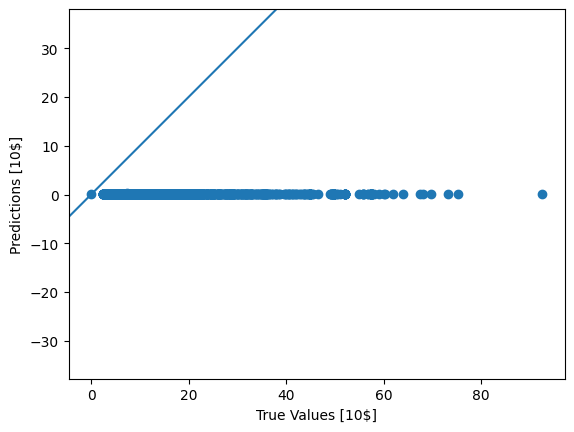

In [40]:
validation_predictions = model.predict(validation_df_scaled).flatten()

plt.scatter(validation_labels, validation_predictions)
plt.xlabel('True Values [10$]')
plt.ylabel('Predictions [10$]')
plt.axis('equal')
plt.xlim(plt.xlim())
plt.ylim(plt.ylim())
_ = plt.plot([-100, 100], [-100, 100])


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


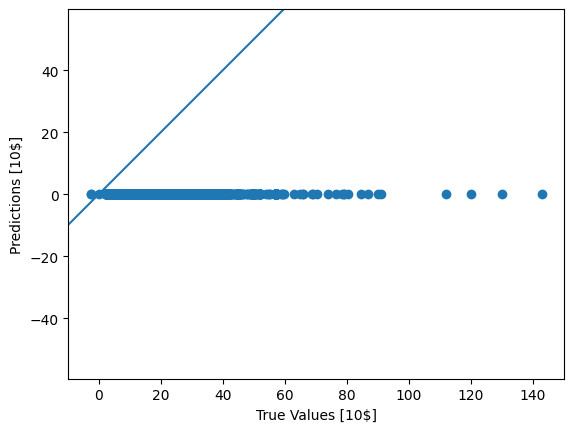

In [41]:
test_predictions = model.predict(test_scaled).flatten()

plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [10$]')
plt.ylabel('Predictions [10$]')
plt.axis('equal')
plt.xlim(plt.xlim())
plt.ylim(plt.ylim())
_ = plt.plot([-100, 100], [-100, 100])


In [42]:
predictionKaggle = model.predict(testKaggle_scaled, batch_size=128, verbose=1)


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [43]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())


In [44]:
print(np.argmax(test_predictions))
print(test_predictions[np.argmax(test_predictions)])
print(test_labels[np.argmax(test_predictions)])
test_df.iloc[np.argmax(test_predictions)]


9176
0.23167071
5.3


pickup_longitude        0.0
pickup_latitude         0.0
dropoff_longitude       0.0
dropoff_latitude        0.0
year                 2010.0
month                  12.0
day                     6.0
hour                   17.0
weekday                 0.0
night                   0.0
late_night              1.0
rush_hour               1.0
latdiff                 0.0
londiff                 0.0
manhattan               0.0
distance                0.0
Name: 4461, dtype: float64

In [45]:
print(np.argmin(test_predictions))
print(test_predictions[np.argmin(test_predictions)])
print(test_labels[np.argmin(test_predictions)])
test_df.iloc[np.argmin(test_predictions)]


5
0.026306666
4.9


pickup_longitude      -73.985321
pickup_latitude        40.741497
dropoff_longitude     -73.992424
dropoff_latitude       40.749493
year                 2009.000000
month                   2.000000
day                     2.000000
hour                    5.000000
weekday                 0.000000
night                   0.000000
late_night              1.000000
rush_hour               0.000000
latdiff                 0.007996
londiff                 0.007103
manhattan               0.015099
distance                0.010695
Name: 45869, dtype: float64

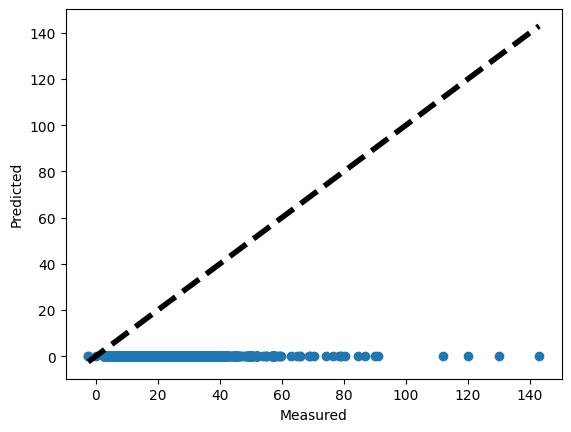

In [46]:
fig, ax = plt.subplots()
ax.scatter(test_labels, test_predictions)
ax.plot([test_labels.min(), test_labels.max()], [test_labels.min(), test_labels.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()


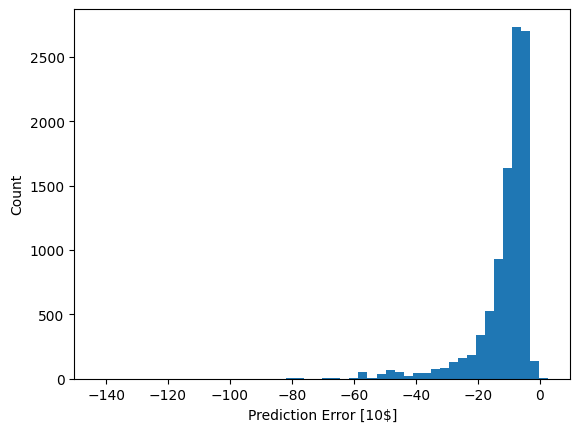

In [47]:
error = test_predictions - test_labels
plt.hist(error, bins = 50)
plt.xlabel("Prediction Error [10$]")
_ = plt.ylabel("Count")


In [48]:
# output prediction

output_submission(testKaggle, predictionKaggle, 'key', 'fare_amount', SUBMISSION_NAME)


Output complete


In [49]:
#print(prediction[9000])
#print(test_labels[9000])
